In [ ]:
# ==== Config ====
import os, numpy as np, pandas as pd, scanpy as sc
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt

# Folder with per‑core AnnData after RCTD transfer
project_dir = "/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd"
os.chdir(project_dir)
print("CWD ->", Path.cwd())

OUT = Path("/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd")

GLOB_PATTERN = "*.h5ad"      # what you used before

# QC thresholds — tweak if needed
MIN_MEDIAN_COUNTS = 20                 # hard fail if median counts/cell < this
MIN_MEDIAN_GENES  = 20                 # hard fail if median genes/cell  < this

# where to save outputs (CSVs, figs, exclude list)
QC_DIR   = "/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/qc_outputs"
FIG_DIR  = f"{QC_DIR}/figs"
EXCL_DIR = f"{QC_DIR}/exclusions"


plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10
})
Path(QC_DIR).mkdir(exist_ok=True); Path(FIG_DIR).mkdir(parents=True, exist_ok=True); Path(EXCL_DIR).mkdir(parents=True, exist_ok=True)


CWD -> /mnt/disks/ext_hd/chiba/adatas_with_rctd


In [7]:
from pathlib import Path

print("CWD:", Path.cwd())

# 1) Common OUT locations relative to this notebook
for p in [Path("OUT"), Path("../OUT"), Path("../../OUT")]:
    print(f"{p}  exists={p.exists()}  "
          f"*.h5ad={len(list(p.glob('*.h5ad')))}  "
          f"*with*rctd*.h5ad={len(list(p.glob('*with*rctd*.h5ad')))}")

# 2) Search anywhere under the repo for h5ad files mentioning rctd
hits = sorted(Path(".").rglob("*with*rctd*.h5ad"))
print("\nFound these candidate files:")
for h in hits[:20]:  # show first 20
    print(" -", h)
print(f"Total hits: {len(hits)}")


CWD: /mnt/disks/ext_hd/chiba/adatas_with_rctd
OUT  exists=False  *.h5ad=0  *with*rctd*.h5ad=0
../OUT  exists=False  *.h5ad=0  *with*rctd*.h5ad=0
../../OUT  exists=False  *.h5ad=0  *with*rctd*.h5ad=0

Found these candidate files:
 - adata_AA1_Core_with_rctd.h5ad
 - adata_AA1_Edge_with_rctd.h5ad
 - adata_AA2_Edge_with_rctd.h5ad
 - adata_AA2__Core_with_rctd.h5ad
 - adata_AA3_Core_with_rctd.h5ad
 - adata_AA3_Edge_with_rctd.h5ad
 - adata_Control_1_with_rctd.h5ad
 - adata_Control_2_with_rctd.h5ad
 - adata_GBM1-Core_with_rctd.h5ad
 - adata_GBM1-Edge_with_rctd.h5ad
 - adata_GBM10-Core_with_rctd.h5ad
 - adata_GBM10-Edge_with_rctd.h5ad
 - adata_GBM2-Core_with_rctd.h5ad
 - adata_GBM2-Edge_with_rctd.h5ad
 - adata_GBM3-Core_with_rctd.h5ad
 - adata_GBM3-Edge_with_rctd.h5ad
 - adata_GBM4-Core_with_rctd.h5ad
 - adata_GBM4-Edge_with_rctd.h5ad
 - adata_GBM5-Core_with_rctd.h5ad
 - adata_GBM5-Edge_with_rctd.h5ad
Total hits: 40


### Load all cores + compute QC table

In [9]:
files = sorted(Path(OUT).glob(GLOB_PATTERN))
print(f"Found {len(files)} h5ad files")
if not files:
    raise FileNotFoundError(f"No files matched {OUT}/{GLOB_PATTERN}")

rows = []
for f in files:
    ad = sc.read_h5ad(f)
    core = Path(f).stem.replace("_with_rctd","").replace("_","-")
    # robustly locate counts/genes columns (fall back to scanpy defaults)
    counts_col = "total_counts" if "total_counts" in ad.obs.columns else "n_counts" if "n_counts" in ad.obs.columns else None
    genes_col  = "n_genes_by_counts" if "n_genes_by_counts" in ad.obs.columns else None
    if counts_col is None:
        raise KeyError(f"{core}: cannot find counts column in .obs")
    if genes_col is None:
        raise KeyError(f"{core}: cannot find genes column in .obs")

    rows.append({
        "core": core,
        "n_cells": ad.n_obs,
        "median_counts": float(np.median(ad.obs[counts_col].values)),
        "median_genes":  float(np.median(ad.obs[genes_col].values)),
        "p10_counts":    float(np.percentile(ad.obs[counts_col].values, 10)),
        "p90_counts":    float(np.percentile(ad.obs[counts_col].values, 90)),
        "p10_genes":     float(np.percentile(ad.obs[genes_col].values, 10)),
        "p90_genes":     float(np.percentile(ad.obs[genes_col].values, 90)),
    })

qc = pd.DataFrame(rows).sort_values(["median_counts","median_genes"])
qc.to_csv(f"{QC_DIR}/core_qc_summary.csv", index=False)
qc.head()


Found 40 h5ad files


,core,n_cells,median_counts,median_genes,p10_counts,p90_counts,p10_genes,p90_genes
13,adata-GBM2-Edge,2387,17.0,15.0,10.0,35.000000,9.0,29.0
7,adata-Control-2,8108,18.0,16.0,10.0,38.000000,10.0,33.0
6,adata-Control-1,5879,40.0,34.0,16.0,80.199707,15.0,59.0
24,adata-GBM8-Core,1299,74.0,39.0,18.0,200.000000,14.0,73.0
3,adata-AA2--Core,1087,83.0,51.0,27.0,207.399963,21.0,78.0


### Flag outliers + save exclude list
This uses both hard thresholds (those ~10–20 medians we discussed) and an IQR rule to catch extreme stragglers.

In [10]:
qc = pd.read_csv(f"{QC_DIR}/core_qc_summary.csv")

# hard fails
hard_fail = (qc["median_counts"] < MIN_MEDIAN_COUNTS) | (qc["median_genes"] < MIN_MEDIAN_GENES)

# IQR-based outliers (very conservative)
def iqr_low(s, k=1.5):
    q1,q3 = s.quantile(0.25), s.quantile(0.75)
    return s < (q1 - k*(q3-q1))

iqr_counts_low = iqr_low(qc["median_counts"], k=1.5)
iqr_genes_low  = iqr_low(qc["median_genes"],  k=1.5)

qc["flag_outlier"] = hard_fail | iqr_counts_low | iqr_genes_low
exclude = qc.loc[qc["flag_outlier"], "core"].tolist()
include = qc.loc[~qc["flag_outlier"], "core"].tolist()

print("=== Exclusion summary ===")
print(qc[["core","n_cells","median_counts","median_genes","flag_outlier"]].to_string(index=False))
print(f"\nExclude ({len(exclude)}): {exclude}")

# save
pd.Series(exclude, name="core").to_csv(f"{EXCL_DIR}/exclude_cores.txt", index=False, header=False)
qc.to_csv(f"{QC_DIR}/core_qc_summary_with_flags.csv", index=False)


=== Exclusion summary ===
               core  n_cells  median_counts  median_genes  flag_outlier
    adata-GBM2-Edge     2387           17.0          15.0          True
    adata-Control-2     8108           18.0          16.0          True
    adata-Control-1     5879           40.0          34.0         False
    adata-GBM8-Core     1299           74.0          39.0         False
    adata-AA2--Core     1087           83.0          51.0         False
    adata-GBM2-Core     5735          102.0          47.0         False
    adata-GBM5-Edge     4427          105.0          56.0         False
    adata-GBM1-Edge     4660          113.0          52.0         False
   adata-GBM10-Edge     1958          117.0          65.0         False
   adata-GBM10-Core    12147          120.0          54.0         False
    adata-GBM5-Core     8179          131.0          60.0         False
    adata-GBM1-Core     7206          136.0          53.0         False
  adata-Oligo2-Edge     3871          

#### Figure A: global distributions (counts + genes)

Panel label “A”; one PDF/PNG each.

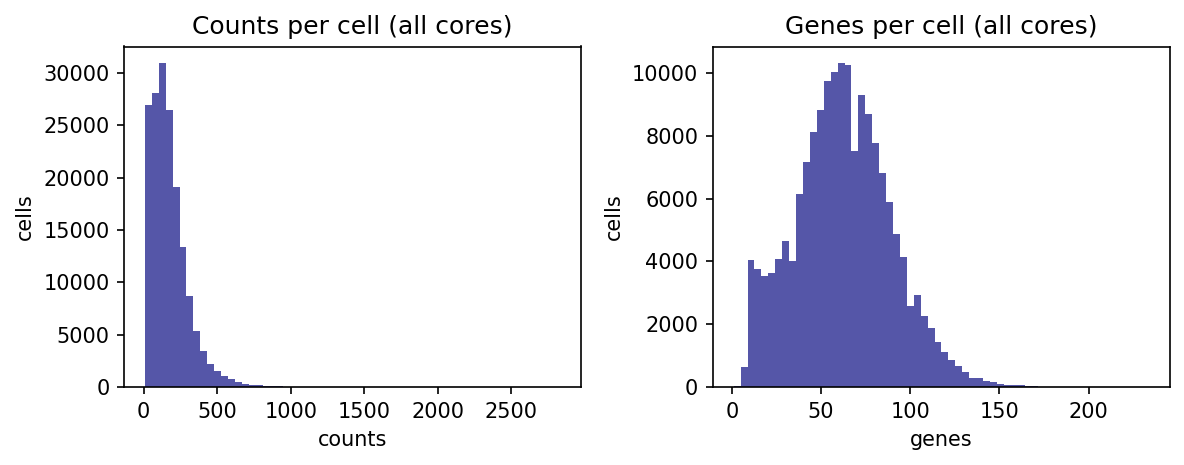

In [18]:
# We already computed global distributions elsewhere; this reproduces them with a clean style.
all_counts = []
all_genes  = []
for f in files:
    ad = sc.read_h5ad(f)
    counts_col = "total_counts" if "total_counts" in ad.obs.columns else "n_counts"
    genes_col  = "n_genes_by_counts"
    all_counts.append(ad.obs[counts_col].values)
    all_genes.append(ad.obs[genes_col].values)

import numpy as np, matplotlib.pyplot as plt
counts = np.concatenate(all_counts)
genes  = np.concatenate(all_genes)

fig, axes = plt.subplots(1,2, figsize=(8,3.2))
axes[0].hist(counts, bins=60, color="#5556A8")
axes[0].set_title("Counts per cell (all cores)")
axes[0].set_xlabel("counts"); axes[0].set_ylabel("cells")

axes[1].hist(genes, bins=60, color="#5556A8")
axes[1].set_title("Genes per cell (all cores)")
axes[1].set_xlabel("genes"); axes[1].set_ylabel("cells")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/A_global_counts_genes.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/A_global_counts_genes.pdf", bbox_inches="tight")
plt.show()


#### Figure B: per-core medians, with outliers highlighted
This is the “bar plot by core” the review discussed; excluded cores in red; thresholds drawn.

/tmp/ipykernel_6363/1553392042.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(order, rotation=90)
/tmp/ipykernel_6363/1553392042.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(order, rotation=90)


/tmp/ipykernel_6363/1553392042.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


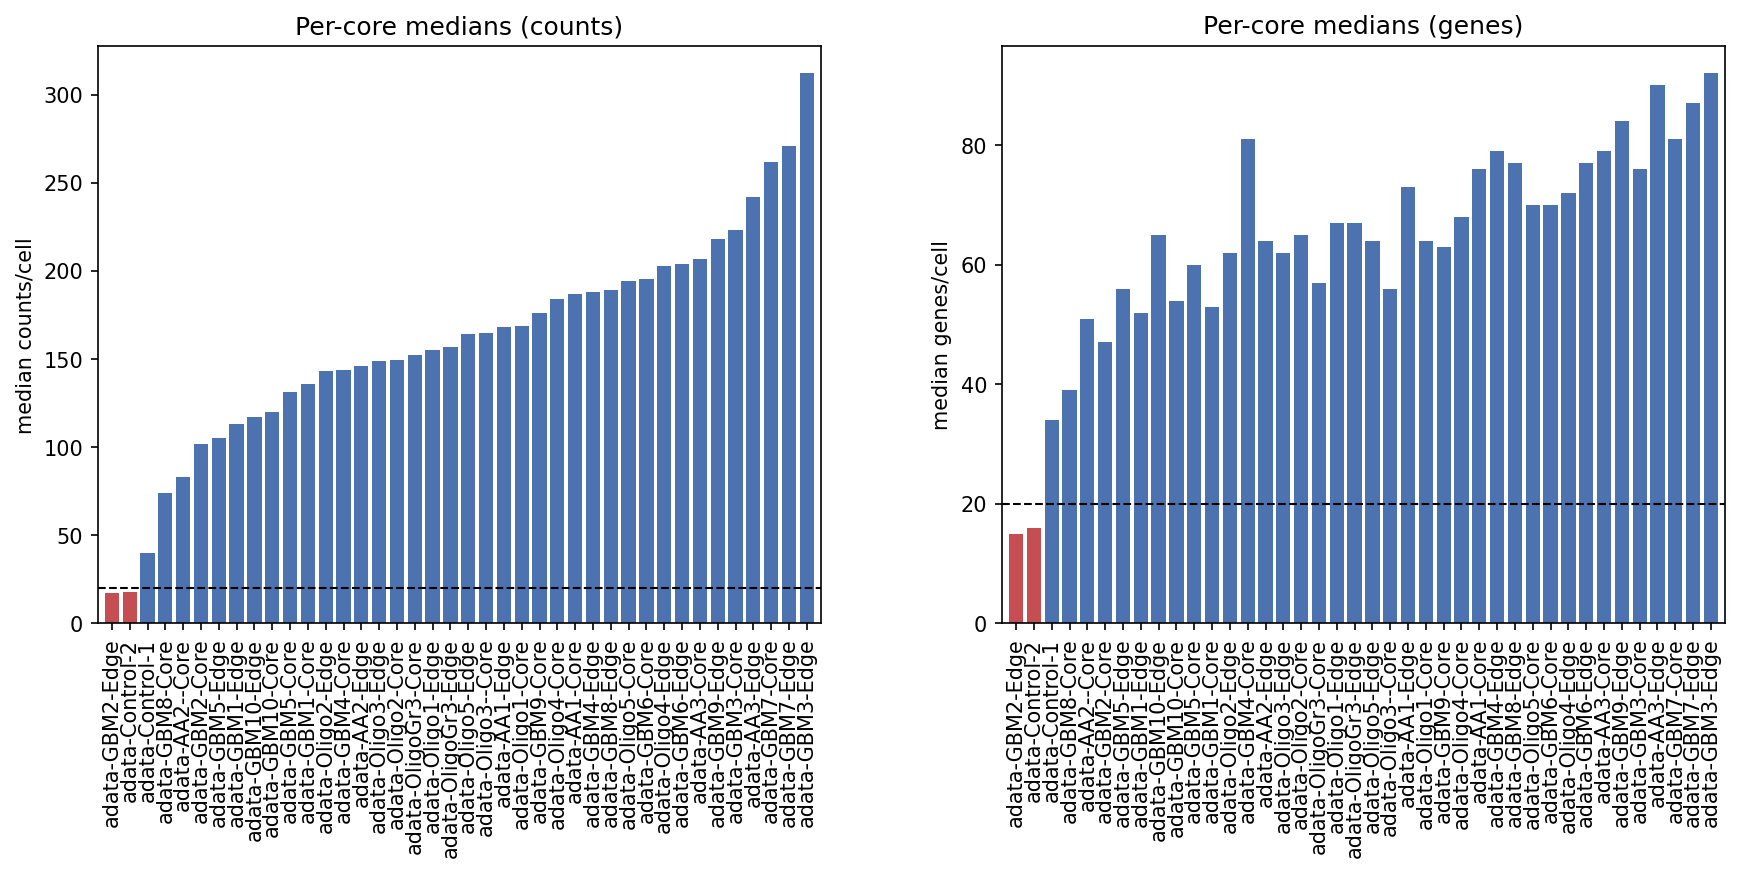

In [17]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

qc_plot = qc.copy()
qc_plot["color"] = np.where(qc_plot["flag_outlier"], "#C44E52", "#4C72B0")
order = qc_plot.sort_values("median_counts")["core"]

fig = plt.figure(figsize=(14,5))
gs  = gridspec.GridSpec(1,2, width_ratios=[1,1], wspace=0.25)

# counts
ax1 = fig.add_subplot(gs[0,0])
ax1.bar(qc_plot.set_index("core").loc[order].index,
        qc_plot.set_index("core").loc[order,"median_counts"], color=qc_plot.set_index("core").loc[order,"color"])
ax1.axhline(MIN_MEDIAN_COUNTS, color="k", ls="--", lw=1)
ax1.set_xticklabels(order, rotation=90)
ax1.set_ylabel("median counts/cell")
ax1.set_title("Per-core medians (counts)")

# genes
ax2 = fig.add_subplot(gs[0,1])
ax2.bar(qc_plot.set_index("core").loc[order].index,
        qc_plot.set_index("core").loc[order,"median_genes"], color=qc_plot.set_index("core").loc[order,"color"])
ax2.axhline(MIN_MEDIAN_GENES, color="k", ls="--", lw=1)
ax2.set_xticklabels(order, rotation=90)
ax2.set_ylabel("median genes/cell")
ax2.set_title("Per-core medians (genes)")

for ax in (ax1, ax2):
    ax.margins(x=0.01)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/B_per_core_medians_with_outliers.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/B_per_core_medians_with_outliers.pdf", bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd, re

sns.set_theme(style="whitegrid", context="talk")

# --- derive group per core (edit the regex map if yours differ) ---
def core_to_group(core: str) -> str:
    # Examples: adata_AA1_Core, adata_GBM5_Edge, adata_Oligo3_Core, adata_Control_1
    if re.search(r"GBM", core, re.I):   return "GBM"
    if re.search(r"Oligo", core, re.I): return "Oligo"
    if re.search(r"AA|Astro", core, re.I): return "Astro"
    if re.search(r"Control", core, re.I):  return "Control"
    return "Other"

qc_plot = qc.copy()
qc_plot["group"] = qc_plot["core"].map(core_to_group)

# order and n per group for labeling
grp_counts = qc_plot.groupby("group")["core"].nunique().sort_values()
order = grp_counts.index.tolist()
lab_with_n = {g: f"{g}\n(n={grp_counts[g]})" for g in order}
qc_plot["group_n"] = qc_plot["group"].map(lab_with_n)

# colors (edit to match your palette)
palette = {"Astro":"#4C72B0","GBM":"#C44E52","Oligo":"#55A868","Control":"#8172B2","Other":"#64B5CD"}

def box_swarm(ax, ycol, title, thresh=None):
    sns.boxplot(data=qc_plot, x="group_n", y=ycol, order=[lab_with_n[g] for g in order],
                whis=1.5, showcaps=True, fliersize=0, width=0.6, boxprops=dict(alpha=.35),
                medianprops=dict(color="k", linewidth=1), ax=ax, color="lightgray")
    sns.stripplot(data=qc_plot, x="group_n", y=ycol, hue="group", order=[lab_with_n[g] for g in order],
                  palette=palette, ax=ax, dodge=False, size=5, alpha=.9)
    if thresh is not None:
        ax.axhline(thresh, ls="--", lw=1, color="k")
    ax.set_xlabel("")
    ax.set_ylabel(f"median {ycol.split('_')[1]}/cell" if "median_" in ycol else ycol)
    ax.set_title(title)
    ax.legend_.remove() if ax.get_legend() else None

fig, axes = plt.subplots(2,1, figsize=(8,8), sharex=True)

box_swarm(axes[0], "median_genes",  "Detected genes per spot\n(median per core; box = IQR)", thresh=MIN_MEDIAN_GENES)
box_swarm(axes[1], "median_counts", "Counts per spot\n(median per core; box = IQR)",      thresh=MIN_MEDIAN_COUNTS)

# make y-lims a touch generous
for ax in axes: ax.margins(y=0.05)
plt.tight_layout()
plt.show()


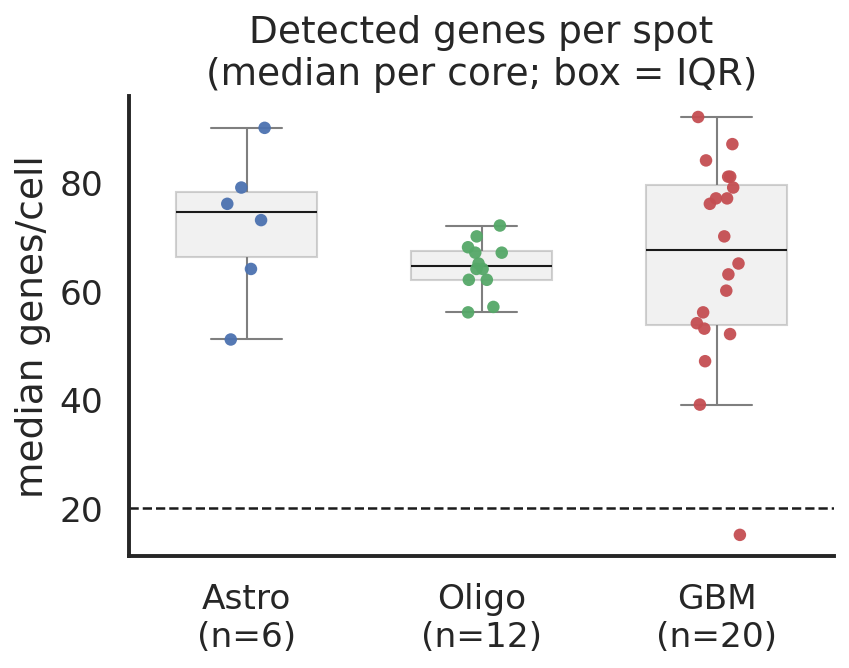

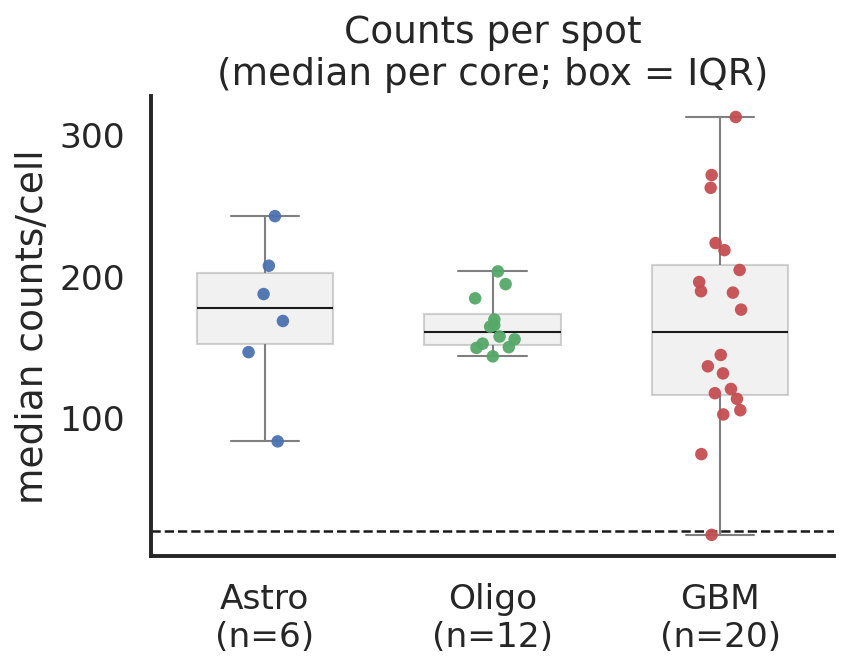

In [32]:
# --- remove Control cores for these figures only ---
groups_keep = ["Astro", "Oligo", "GBM"]      # desired order
qc_plot_nctl = qc_plot[qc_plot["group"].isin(groups_keep)].copy()

# n per group and pretty x labels
grp_counts = qc_plot_nctl.groupby("group")["core"].nunique()
order = [g for g in groups_keep if g in grp_counts.index]
lab_with_n = {g: f"{g}\n(n={grp_counts[g]})" for g in order}
qc_plot_nctl["group_n"] = qc_plot_nctl["group"].map(lab_with_n)
x_order = [lab_with_n[g] for g in order]

# keep palette entries for the remaining groups
palette = {"Astro":"#4C72B0","Oligo":"#55A868","GBM":"#C44E52"}

import seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="white", context="talk")

def make_panel(df, ycol, title, ylabel, thresh=None, outfile=None):
    fig, ax = plt.subplots(figsize=(6,4.8))
    sns.boxplot(data=df, x="group_n", y=ycol, order=x_order,
                whis=1.5, showcaps=True, fliersize=0, width=0.6,
                boxprops=dict(alpha=.35, facecolor="0.85"),
                medianprops=dict(color="k", linewidth=1),
                ax=ax, color="lightgray")
    sns.stripplot(data=df, x="group_n", y=ycol, order=x_order,
                  hue="group", palette=palette, dodge=False, size=6, alpha=.95, ax=ax)
    if thresh is not None:
        ax.axhline(thresh, ls="--", lw=1.2, color="k")
    ax.set_xlabel(""); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(False); sns.despine(ax=ax)
    if ax.get_legend(): ax.legend_.remove()
    plt.tight_layout()
    if outfile: plt.savefig(outfile, bbox_inches="tight")
    plt.show()

# genes (no Control)
make_panel(qc_plot_nctl, "median_genes",
           "Detected genes per spot\n(median per core; box = IQR)",
           "median genes/cell", thresh=MIN_MEDIAN_GENES,
           outfile=f"{FIG_DIR}/genes_per_spot_no_control.pdf")

# counts (no Control)
make_panel(qc_plot_nctl, "median_counts",
           "Counts per spot\n(median per core; box = IQR)",
           "median counts/cell", thresh=MIN_MEDIAN_COUNTS,
           outfile=f"{FIG_DIR}/counts_per_spot_no_control.pdf")


In [34]:
import re, numpy as np, pandas as pd
from pathlib import Path

# --- thresholds you already used on the plots ---
MIN_MEDIAN_GENES = 20
MIN_MEDIAN_COUNTS = 30  # change if you used a different line

# --- helper: map core -> group (edit if your naming differs) ---
def core_to_group(core: str) -> str:
    if re.search(r"GBM", core, re.I):   return "GBM"
    if re.search(r"Oligo", core, re.I): return "Oligo"
    if re.search(r"AA|Astro", core, re.I): return "Astro"
    return "Other"

qc2 = qc.copy()
if "group" not in qc2.columns:
    qc2["group"] = qc2["core"].map(core_to_group)

# rule 1: hard thresholds
qc2["low_genes"]  = qc2["median_genes"]  < MIN_MEDIAN_GENES
qc2["low_counts"] = qc2["median_counts"] < MIN_MEDIAN_COUNTS
qc2["reason"] = np.select(
    [qc2["low_genes"] & qc2["low_counts"], qc2["low_genes"], qc2["low_counts"]],
    ["genes+counts", "genes", "counts"],
    default="ok"
)

# (optional) rule 2: group-wise IQR outliers (lower whisker)
def iqr_low_flags(df, col):
    g = df.groupby("group")[col]
    q1 = g.quantile(0.25)
    q3 = g.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    return df[col] < df["group"].map(low)

qc2["iqr_low_genes"]  = iqr_low_flags(qc2, "median_genes")
qc2["iqr_low_counts"] = iqr_low_flags(qc2, "median_counts")

# combine reasons (hard thresholds first; add IQR tags if applicable)
def combine_reason(row):
    r = row["reason"]
    tags = []
    if row["iqr_low_genes"]:  tags.append("IQR_genes")
    if row["iqr_low_counts"]: tags.append("IQR_counts")
    if r == "ok" and tags: r = "+".join(tags)
    elif tags: r = f"{r}+" + "+".join(tags)
    return r

qc2["reason"] = qc2.apply(combine_reason, axis=1)

# final outliers
outliers = qc2[qc2["reason"] != "ok"].sort_values(["group","reason","median_genes","median_counts"])

# show & save
cols = ["core","group","median_genes","median_counts","reason"]
display(outliers[cols])

out_dir = Path("qc_outputs/exclusions"); out_dir.mkdir(parents=True, exist_ok=True)
outliers[cols].to_csv(out_dir/"outlier_cores.csv", index=False)
(out_dir/"exclude_cores.txt").write_text("\n".join(outliers["core"].tolist()))

print(f"\nSaved: {out_dir/'outlier_cores.csv'}")
print(f"Saved: {out_dir/'exclude_cores.txt'}")
print("\nCounts by group and reason:")
print(outliers.groupby(["group","reason"])["core"].count())


,core,group,median_genes,median_counts,reason
0,adata-GBM2-Edge,GBM,15.0,17.0,genes+counts+IQR_genes
1,adata-Control-2,Other,16.0,18.0,genes+counts



Saved: qc_outputs/exclusions/outlier_cores.csv
Saved: qc_outputs/exclusions/exclude_cores.txt

Counts by group and reason:
group  reason                
GBM    genes+counts+IQR_genes    1
Other  genes+counts              1
Name: core, dtype: int64


In [20]:
from pathlib import Path
import scanpy as sc

OUT = Path("/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd")  # or your absolute path
exclude_path = Path("qc_outputs/exclusions/exclude_cores.txt")
exclude = set(line.strip() for line in exclude_path.read_text().splitlines()) if exclude_path.exists() else set()
print("Excluding:", sorted(exclude))

adatas = []
for p in sorted(Path(OUT).glob("*_with_rctd.h5ad")):
    core = p.stem.replace("_with_rctd","")
    if core in exclude:
        print("skip", core)
        continue
    ad = sc.read_h5ad(p)
    ad.obs["core"] = core
    adatas.append(ad)

adata_all = sc.concat(adatas, join="outer", label="batch", index_unique=None)
print("Merged cells:", adata_all.n_obs, "| cores:", adata_all.obs["core"].nunique())


Excluding: ['adata-Control-2', 'adata-GBM2-Edge']


Merged cells: 169574 | cores: 40
